In [38]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
df_traj = pd.read_excel("charades_traj.xlsx", sheet_name="all")
df_traj = df_traj.dropna(subset=['id'])
df_traj.columns

Index(['Unnamed: 0', 'id', 'label', 'shapes', 'x1', 'y1', 'ori1', 'x2', 'y2',
       'ori2'],
      dtype='object')

In [62]:
df_traj.shape

(1156, 12)

In [60]:
# Convert any stringified lists to real lists
for col in ["x1", "y1", "x2", "y2"]:
    df_traj[col] = df_traj[col].apply(
        lambda x: [float(v) for v in ast.literal_eval(x)] if isinstance(x, str)
        else [float(v) for v in x] if isinstance(x, list)
        else x
    )

In [61]:
frame_per_sec = 50
df_traj["frameN"] = df_traj["x1"].apply(lambda x: len(x))
df_traj["duration"] = df_traj["frameN"].apply(lambda x: x/frame_per_sec)

In [42]:
def add_summary_metrics(row):
    x1 = np.array(row["x1"])
    y1 = np.array(row["y1"])
    x2 = np.array(row["x2"])
    y2 = np.array(row["y2"])

    # --- speed1 ---
    speed1 = np.sqrt(np.diff(x1)**2 + np.diff(y1)**2)

    # --- speed2 ---
    speed2 = np.sqrt(np.diff(x2)**2 + np.diff(y2)**2)

    # --- relative distance ---
    relDist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    return pd.Series({
        "speed1": speed1,
        "speed2": speed2,
        "relativeDistance": relDist,
        "meanSpeed1": speed1.mean(),
        "meanSpeed2": speed2.mean(),
        "meanRelativeDistance": relDist.mean()
    })

In [43]:
# Add new columns to existing df
df_traj[["speed1", "speed2", "relativeDistance",
        "meanSpeed1", "meanSpeed2", "meanRelativeDistance"]] = df_traj.apply(add_summary_metrics, axis=1)

In [46]:
def get_summary(metric):
    return {
        "Mean": np.mean(metric),
        "Min": np.min(metric),
        "Median": np.median(metric),
        "Max": np.max(metric),
    }

In [47]:
metrics = {
    "Duration (frame)": df_traj.frameN,
    "Duration (seconds)": df_traj.duration,
    "Speed of Agent A (aggregated)": df_traj.meanSpeed1,
    "Speed of Agent B (aggregated)": df_traj.meanSpeed2,
    "Relative Distance (aggregated)": df_traj.meanRelativeDistance,
}

In [48]:
summary_df = pd.DataFrame(
    {name: get_summary(metric) for name, metric in metrics.items()}
).T  # transpose so rows = metrics

summary_df

,Mean,Min,Median,Max
Duration (frame),333.457612,7.000000,239.000000,2554.000000
Duration (seconds),6.669152,0.140000,4.780000,51.080000
Speed of Agent A (aggregated),15.791914,0.000000,8.858921,255.647127
Speed of Agent B (aggregated),4.855347,0.000000,0.446346,151.406839
Relative Distance (aggregated),688.392229,54.578542,562.185517,2363.295086


In [57]:
def get_summary_interframe(metric):
    flattened = np.concatenate(metric.values)
    return get_summary(flattened)

In [55]:
metrics_interframe = {
    "Speed of Agent A (inter-frame)": df_traj.speed1,
    "Speed of Agent B (inter-frame)": df_traj.speed2,
    "Relative Distance (inter-frame)": df_traj.relativeDistance,
}

In [58]:
summary_df_interframe = pd.DataFrame(
    {name: get_summary_interframe(metric) for name, metric in metrics_interframe.items()}
).T  # transpose so rows = metrics

summary_df_interframe

,Mean,Min,Median,Max
Speed of Agent A (inter-frame),11.675976,0.000000,2.114427,1083.428811
Speed of Agent B (inter-frame),6.515051,0.000000,0.000000,1034.718311
Relative Distance (inter-frame),695.994529,0.900278,580.928900,4154.335688


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


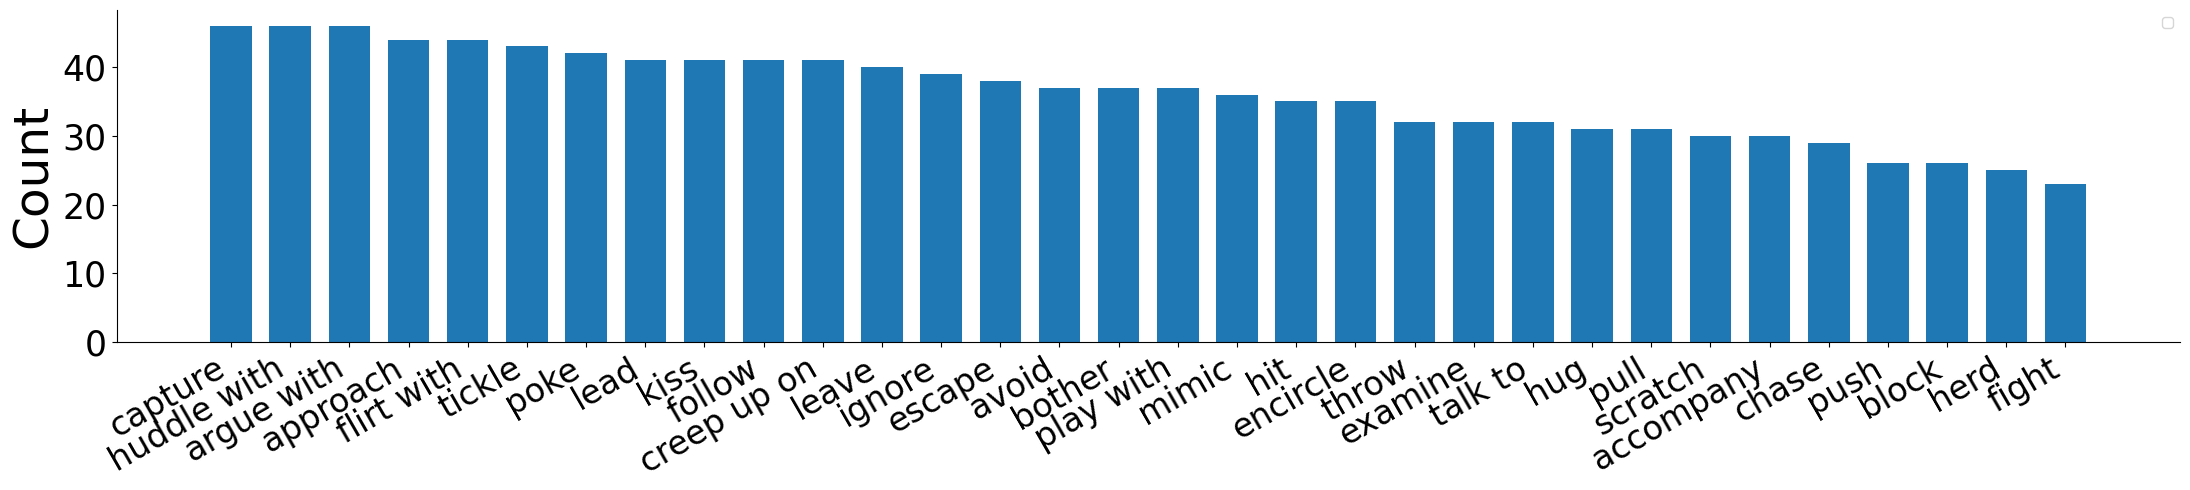

In [66]:
video_distr = df_traj.label.value_counts()

labels = video_distr.index.tolist()
values = video_distr.values
x = np.arange(len(labels))  # explicit x positions

f, ax = plt.subplots(figsize=(22, 5))
plt.bar(x, values, width=0.7)

plt.xticks(x, labels, rotation=30, ha='right', fontsize=24)  
plt.yticks(fontsize=25)
plt.ylabel('Count', fontsize=35)
plt.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
f.savefig('supp_num_videos.png', bbox_inches='tight', dpi = 300)